# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow
Resouces:
* https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
* https://www.learnpytorch.io/01_pytorch_workflow/

In [8]:
what_we_are_covering = {1: "data (prepare and load)",
                        2: "build model",
                        3: "fitting the model to data (training)",
                        4: "making predictions and evaluating a model (inference)",
                        5: "saving and loading model",
                        6: "putting it all together"}

what_we_are_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading model',
 6: 'putting it all together'}

In [9]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# check pytorch version
torch.__version__

'2.7.0+cu118'

## 1. Data (preparing and loading)

Data can be:
* Excel spreadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some **known** data using the linear regression formula: Y = a + bX

We'll use a linear regression formula to build a straight line with known **parameters**.

In [10]:
# Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [11]:
len(X), len(Y)

(50, 50)

### Splitting data into training and test sets

Generalization - The ability of a machine learning model to perform well on data it hasn't seen before.

In [12]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(X_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

How might we better visualize our data

This is where the data explorer's motto comes in!

In [13]:
def plot_predictions(train_data=X_train, 
                     train_labels=Y_train,
                     test_data=X_test,
                     test_labels=Y_test,
                     predictions=None):
    """ Plots training data, test data and compares predictions. """
    plt.Figure(figsize=(10,7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are these predictions?
    if predictions is not None:
        # plot predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    # show the legend
    plt.legend(prop={"size": 14})

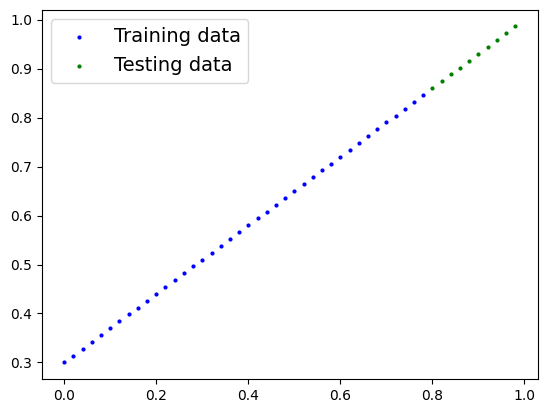

In [14]:
plot_predictions()

## Build model

Our first PyTorch Model

What our model does?
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient Descent
2. Backpropogation

In [15]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module):     # <- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
    
    # Forward method to define the computations in the model
    def forward(self, x:torch.Tensor) -> torch.Tensor:      # "x" is the input data
        return self.weights * x + self.bias     # linear regression formula

### PyTorch model building essentials:

* torch.nn - contains all the buildings of the computational graph (neural networks)
* torch.nn.Parameter - what parameters a model should try and learn, often a PyTorch layer from torch.nn will set these for us.
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward().
* torch.optim - this is where optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require us to overwrite the forward(), this method defines what happens in the forward computation.

In [16]:
# Create a manual seed
torch.manual_seed(42)

# create an instance of the model
model_0 = LinearRegressionModel()
# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
# List of parameters (name)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
weight, bias

(0.7, 0.3)

### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how it predicts `Y_test` based on `X_test`.

When we pass data through our model, it's going to run through forward method.

In [19]:
# make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)       # can do the same with torch.no_grad() but torch.inference_mode() is preferred.

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [20]:
Y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

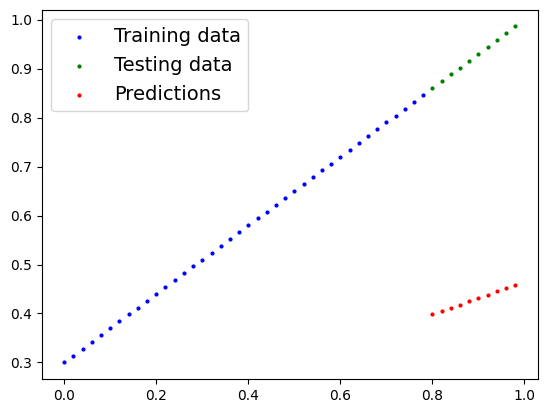

In [21]:
plot_predictions(predictions=y_preds)

## Train model

The whole idea of training is for a model is to move from some *unknown* parameters(these may be random) to some *known* parameters.

Or in other words from a poor representation of data to a better representation of data.

One way to measure how poor a model's predictions are to use loss functions.
https://docs.pytorch.org/docs/stable/nn.html#loss-functions

* Note: Loss functions may also be called cost function or criterion in different areas. We call it loss function.

* **Loss Function:** A function to measure how wrong your model's predictions are to real outputs, lower is better.

* **Optimizers:** Take into account the loss of a model and adjusts the model's parameters. (e.g. weights and bias). https://docs.pytorch.org/docs/stable/optim.html

Specifically for PyTorch, we need:
* Training loop
* Testing loop

In [22]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.01)        # lr is most important hyperparameter

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` function) to make predictions on the data - also called forward propogation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - to move backward through the network to calculate gradients of each parameters of our model with respect to the loss. (**backpropogation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss. (**gradient descent**)

In [23]:
# epochs - an epoch is one loop through the data
epochs = 200

# Tracking different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train()     # train mode in PyTorch sets all parameters that require gradients to require gradient.

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, Y_train)
    print(f"Loss {epoch+1}: {loss}")
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropogation on the loss wrt the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step()    # by default changes will be accumulated through the loop... so we have to zero them in step 3

    ### Testing
    model_0.eval()      # turns off different settings in the model not needed for evaluation/testing
    with torch.inference_mode():    # turns off gradient tracking & a couple more things behind the scenes 
        # 1. Do the Forward pass 
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, Y_test)
        
    if epoch%10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Test: {loss} | Test loss: {test_loss}")

Loss 1: 0.31288138031959534
Epoch: 0 | Test: 0.31288138031959534 | Test loss: 0.48106518387794495
Loss 2: 0.3013603389263153
Loss 3: 0.28983935713768005
Loss 4: 0.2783183455467224
Loss 5: 0.26679736375808716
Loss 6: 0.2552763521671295
Loss 7: 0.24375534057617188
Loss 8: 0.23223432898521423
Loss 9: 0.22071333229541779
Loss 10: 0.20919232070446014
Loss 11: 0.1976713240146637
Epoch: 10 | Test: 0.1976713240146637 | Test loss: 0.3463551998138428
Loss 12: 0.18615034222602844
Loss 13: 0.1746293306350708
Loss 14: 0.16310831904411316
Loss 15: 0.1515873372554779
Loss 16: 0.14006635546684265
Loss 17: 0.1285453587770462
Loss 18: 0.11702437698841095
Loss 19: 0.1060912236571312
Loss 20: 0.09681284427642822
Loss 21: 0.08908725529909134
Epoch: 20 | Test: 0.08908725529909134 | Test loss: 0.21729660034179688
Loss 22: 0.08227583020925522
Loss 23: 0.07638873159885406
Loss 24: 0.07160007208585739
Loss 25: 0.06747635453939438
Loss 26: 0.06395438313484192
Loss 27: 0.06097004935145378
Loss 28: 0.0584581904113

In [24]:
import numpy as np
loss_values_array = np.array(torch.tensor(loss_values).cpu().numpy())
test_loss_values_array = np.array(torch.tensor(test_loss_values).cpu().numpy())

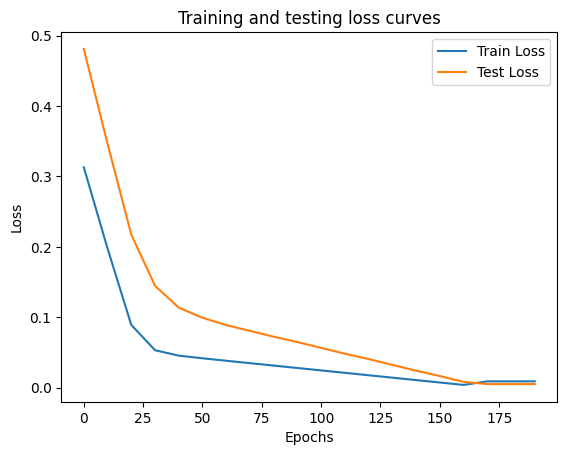

In [25]:
# Plot loss curves 
plt.plot(epoch_count, loss_values_array, label="Train Loss")
plt.plot(epoch_count, test_loss_values_array, label="Test Loss")
plt.title("Training and testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [27]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

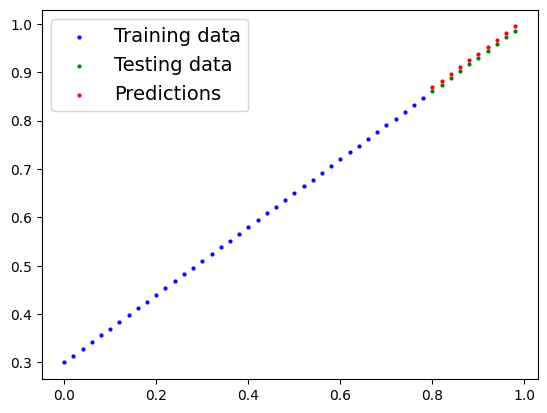

In [28]:
plot_predictions(predictions=y_preds_new)

## Saving a model in PyTorch

There are three main methods for saving and loading model in PyTorch
1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - allows you to load a model's saved state dictionary

https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference

In [29]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create a model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pt"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

# 3. Save the model - state_dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow_model_0.pt


In [30]:
!ls  -l models

total 4
-rw-r--r-- 1 Ayushman Singh 197121 2117 Sep 27 13:14 01_pytorch_workflow_model_0.pt


## Loading a PyTorch model

Since we saved our model's `state_dict()` rather than the entire model, we will create a new instance of our model class and load the saved `state_dict()` into that.

In [31]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [32]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [33]:
# Make some model predictions
loaded_model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [34]:
# Compare loaded model preds with original model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Putting up everything together

In [35]:
# Import PyTorch and Matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt 

# check pytorch version
torch.__version__

'2.7.0+cu118'

Create device agnostic code 

This means if we've got access to GPU, our code will use it (for potentially faster computation).

If no GPU is available, the code will default to using CPU.

In [36]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device {device}")

Using device cuda


### 6.1 Data

In [37]:
# Create some data using the linear regression formula of Y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0 
end = 1
step = 0.02

# Create X and Y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias
X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [38]:
#  Split the data 
train_split = int(0.8*len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]
len(X_train), len(Y_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

In [40]:
def plot_predictions(train_data=X_train, 
                     train_labels=Y_train,
                     test_data=X_test,
                     test_labels=Y_test,
                     predictions=None):
    """ Plots training data, test data and compares predictions. """
    plt.Figure(figsize=(10,7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are these predictions?
    if predictions is not None:
        # plot predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    # show the legend
    plt.legend(prop={"size": 14})

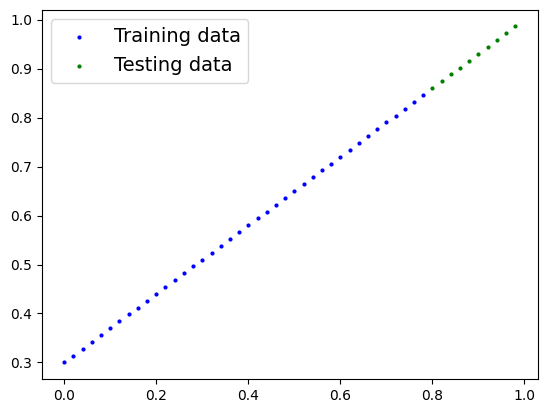

In [41]:
# Plot the data 
# Note: If you don't have plot predictions() function loaded, this will error
plot_predictions(X_train, Y_train, X_test, Y_test)

### 6.2 Builing a PyTorch Linear Model

In [42]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating model parameters
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [43]:
# Check the model's current device
next(model_1.parameters()).device

device(type='cpu')

In [45]:
# Set the model to the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training code

For training we need:
1. Loss Function
2. Optimizer
3. Training loop
4. Testing Loop

In [46]:
# Setup the loss function
loss_fn = nn.L1Loss()

# Setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [47]:
# Let's write a training loop
torch.manual_seed(42)

epochs = 200

# Put data on target device
X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, Y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropogation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, Y_test)
    
    # Print out what's happening
    if epoch%10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.439968079328537 | Test Loss: 0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test Loss: 0.16984669864177704
Epoch: 40 | Loss: 0.09433845430612564 | Test Loss: 0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test Loss: 0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test Loss: 0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test Loss: 0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test Loss: 0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test Loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416

In [48]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

### 6.4 Making and evaluating predictions

In [49]:
# turn the model into evaluation mode
model_1.eval()

# make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

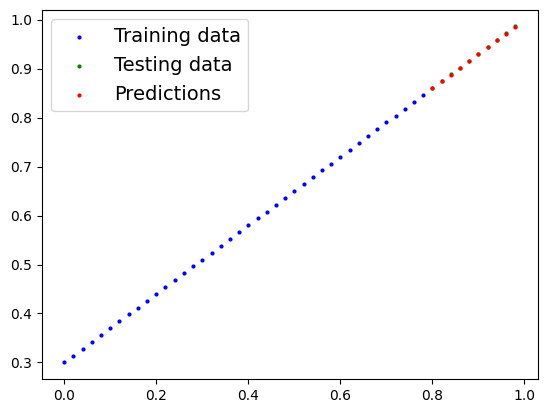

In [50]:
# plot predictions
plot_predictions(predictions=y_preds.cpu())

### 6.5 Saving and loading a trained model

In [52]:
from pathlib import Path

# 1. Create model's directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save  path
MODEL_NAME = "01_pytorch_workflow_model_1.pt"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow_model_1.pt


In [53]:
# Load a pytorch model

# create a new instance of linear regression model V2
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [54]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [55]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [56]:
# Evaluate the loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')